# 01 — Manifold Reconstruction and Eigenspectrum Gate

**v1.1 PU Manifold Curvature.** This notebook is a committed deliverable (shipped WITH
outputs, from a deliberate Restart-and-Run-All — see §0.4). Phase 1 owns §0-§5 of this
file; Phase 2 appends §6 onward, described further in §0.5.

Phase 1 (this plan, 01-01) writes §0-§1: environment/reproducibility, dependency install,
and a permanent smoke-config end-to-end self-test proving every layer of the pipeline
(HF config load → seeded subsample → row-alignment assert → L2 normalize → npz cache →
npz read-back → connectivity check → Isomap fit → joblib cache → joblib read-back) works
before the ~1 GB analysis artifact is ever built.

## §0. Environment & Reproducibility

### §0.1 Python floor

In [1]:
import sys
from pathlib import Path

# Make the notebook-local pu_manifold package importable regardless of how the kernel
# was started (D-01 key link: plain relative import, never installed, never imported
# from src/effdim/).
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

assert sys.version_info >= (3, 11), (
    "This notebook requires Python >= 3.11. pyproject.toml declares >=3.8, which is "
    "stale core-dependency drift tracked as LIB-03: scikit-learn 1.9.0 and the "
    "torch/datasets wheels this notebook installs are the real constraint, not the "
    "declared floor. If you are running on Python 3.10 or earlier, create a separate "
    "notebook kernel for this milestone rather than downgrading the pins in "
    "requirements-notebooks.txt."
)
print(f"Python {sys.version.split()[0]} OK (>= 3.11 required)")

Python 3.14.6 OK (>= 3.11 required)


### §0.2 Dependencies

No `## Package Legitimacy Audit` table exists anywhere under `.planning/` (verified
during planning: `grep -rn "Package Legitimacy" .planning/` returns nothing). Per the
documented fallback policy, every package this phase installs is therefore treated as
`[ASSUMED]` and required human confirmation on the registry before install — this was
Task 1 of the Phase 1 plan (01-01), a `checkpoint:human-verify` with
`gate="blocking-human"` that is **never** auto-approvable. Task 1 was reviewed and
**approved**: `torch==2.13.0+cpu` (PyTorch, `+cpu` wheel from
`https://download.pytorch.org/whl/cpu`), `datasets==5.0.1` (Hugging Face `datasets`),
and `matplotlib==3.11.1` were each confirmed as the legitimate, expected project on
PyPI before this cell was authored or run. `numpy`/`scipy`/`scikit-learn`/`faiss-cpu`
are already core `effdim` dependencies and are deliberately not re-pinned here;
`huggingface_hub`/`hf_xet`/`pyarrow` arrive transitively via `datasets`.

In [2]:
%pip install -q -r requirements-notebooks.txt

Note: you may need to restart the kernel to use updated packages.


### §0.3 Reproducibility header

In [3]:
import subprocess

import numpy as np
import scipy
import sklearn
import faiss
import datasets
import torch

# Defined once here (needed for this header) and restated verbatim in §1.1 so that
# section is self-contained for a reader who jumps straight to §1.
SEED = 20260729

git_sha = subprocess.check_output(
    ["git", "rev-parse", "--short", "HEAD"], text=True
).strip()

print("=== Reproducibility header ===")
print(f"SEED           = {SEED}")
print(f"numpy          = {np.__version__}")
print(f"scipy          = {scipy.__version__}")
print(f"scikit-learn   = {sklearn.__version__}")
print(f"faiss          = {faiss.__version__}")
print(f"datasets       = {datasets.__version__}")
print(f"torch          = {torch.__version__}")
print(f"git commit SHA = {git_sha}")

=== Reproducibility header ===
SEED           = 20260729
numpy          = 2.5.1
scipy          = 1.18.0
scikit-learn   = 1.9.0
faiss          = 1.14.3
datasets       = 5.0.1
torch          = 2.13.0+cpu
git commit SHA = cde9ed9


The git commit SHA is printed for provenance but is **deliberately NOT** part of any
cache key (D-14) — a docstring-only commit must not invalidate a ~1 GB Isomap artifact.
`sklearn`/`numpy`/`scipy` versions, by contrast, **are** part of the fit cache key,
because a library upgrade can silently change numerical results.

### §0.4 Output hygiene policy

1. This notebook is committed **with outputs intact**, produced by a deliberate
   Restart-and-Run-All. It is not run through `nbconvert --clear-output`.
2. `nbstripout` is not installed and no `.gitattributes` filter is added. This repo has
   no pre-commit framework, and adding one for a milestone this size is unwarranted
   ceremony; `nbstripout` is the documented later upgrade path *if* output-diff noise
   ever becomes a real problem, not something adopted pre-emptively.
3. No cell output may embed a bulk array. Outputs here are limited to plots, tables, and
   scalar prints — never a repr of the 10000x768 embedding arrays and never the fitted
   `Isomap` object — so the notebook JSON stays small enough to diff.
4. `.ipynb_checkpoints/` and `notebooks/.cache/` are already present in `.gitignore`
   (verified), so no gitignore change is needed for this phase.

Phase 2, which appends to this same file, inherits this policy rather than re-deciding
it.

### §0.5 Section numbering

Phase 1 owns `§0`-`§5` of this notebook; Phase 2 appends `§6` onward. Existing
sections are never renumbered once written. Subsections use `### §N.M Title`. This
convention, together with D-01's three fixed notebook filenames, is **costly** to change
later: every cache path, cross-notebook check, and doc reference in this milestone is
written against it.

## §1. Smoke-Config End-to-End Self-Test

This section is a **permanent** self-test, not scaffolding to be deleted later: it
exercises every layer this phase touches — HF config load, seeded subsample, row-
alignment assert, L2 normalization, npz cache, npz read-back identity, connectivity
check, deterministic Isomap fit, joblib cache, joblib read-back identity — at a cheap
smoke size (`n_rows=500`) in seconds, before the ~10 minute, ~1 GB analysis fit is ever
paid for.

### §1.1 Configs

In [4]:
# Restated from §0.3 (same value) so this section is self-contained.
SEED = 20260729

SMOKE_CFG = {
    "dataset": "legacysurvey_dinov3_vitb16",
    "seed": SEED,
    "n_rows": 500,
    "normalize": True,
    "n_neighbors": 10,
    "n_components": 4,
    "eigen_solver": "dense",
    "sklearn_version": sklearn.__version__,
    "numpy_version": np.__version__,
    "scipy_version": scipy.__version__,
}

ANALYSIS_CFG = {
    "dataset": "legacysurvey_dinov3_vitb16",
    "seed": SEED,
    "n_rows": 10_000,
    "normalize": True,
    "n_neighbors": None,  # derived by a later plan's connectivity sweep (ISO-01/ISO-02)
    "n_components": None,  # derived in a later plan via the D-12 ceil(median(...)) rule
    "eigen_solver": "dense",
    "sklearn_version": sklearn.__version__,
    "numpy_version": np.__version__,
    "scipy_version": scipy.__version__,
}

print("SMOKE_CFG:   ", SMOKE_CFG)
print("ANALYSIS_CFG:", ANALYSIS_CFG)

SMOKE_CFG:    {'dataset': 'legacysurvey_dinov3_vitb16', 'seed': 20260729, 'n_rows': 500, 'normalize': True, 'n_neighbors': 10, 'n_components': 4, 'eigen_solver': 'dense', 'sklearn_version': '1.9.0', 'numpy_version': '2.5.1', 'scipy_version': '1.18.0'}
ANALYSIS_CFG: {'dataset': 'legacysurvey_dinov3_vitb16', 'seed': 20260729, 'n_rows': 10000, 'normalize': True, 'n_neighbors': None, 'n_components': None, 'eigen_solver': 'dense', 'sklearn_version': '1.9.0', 'numpy_version': '2.5.1', 'scipy_version': '1.18.0'}


`SMOKE_CFG["n_components"] = 4` is a smoke-test constant only — it is **not** the
analysis `n_components`, which a later plan derives from the D-12 rule
(`ceil(median(...))` over the 8 geometric/intrinsic `effdim.compute_dim` keys). Because
`ANALYSIS_CFG` differs from `SMOKE_CFG` in `n_rows` (and, once derived, `n_components`),
the two configs produce different `config_key` hashes by construction — itself the
ISO-05 "a config change produces a new cache key" property, demonstrated concretely in
§1.3 below rather than merely asserted in prose.

### §1.2 Subsample and alignment (smoke)

In [5]:
from pu_manifold import load_subsample, assert_alignment, config_key, joblib_cache

smoke_data = load_subsample(SMOKE_CFG)
alignment_stats = assert_alignment(
    smoke_data["hsc"],
    smoke_data["legacysurvey"],
    smoke_data["row_indices"],
    seed=SEED,
)

print("hsc shape:         ", smoke_data["hsc"].shape)
print("legacysurvey shape:", smoke_data["legacysurvey"].shape)
print("row_indices shape: ", smoke_data["row_indices"].shape)
print("alignment stats:   ", alignment_stats)

hsc shape:          (500, 768)
legacysurvey shape: (500, 768)
row_indices shape:  (500,)
alignment stats:    {'s_true': 0.8455923572483339, 'mu_perm': 0.7171236552581232, 'sd_perm': 0.0030748871782488546, 'z': 41.779972578822736, 'margin_z': 5.0, 'n_permutations': 50, 'row_indices_sha256': '3c22a0439ed2838d364e1d1715afd1f815b5cb7367e40450a95822e09239e035'}


### §1.3 Cache round-trip (smoke)

In [6]:
smoke_data_2 = load_subsample(SMOKE_CFG)
for key in smoke_data:
    assert np.array_equal(smoke_data[key], smoke_data_2[key]), (
        f"{key} differs between the two load_subsample(SMOKE_CFG) calls -- cache "
        f"round-trip is not bit-identical."
    )
print("CACHE HIT: second load_subsample(SMOKE_CFG) call returned bit-identical arrays")

smoke_cfg_changed = dict(SMOKE_CFG, n_rows=SMOKE_CFG["n_rows"] + 1)
key_before = config_key(SMOKE_CFG)
key_after = config_key(smoke_cfg_changed)
print(f"config_key(SMOKE_CFG)               = {key_before}")
print(f"config_key(SMOKE_CFG with n_rows+1) = {key_after}")
assert key_before != key_after, "changing n_rows must change the cache key (ISO-05)"
print("ISO-05: a single config field change demonstrably produces a new cache key")

CACHE HIT: second load_subsample(SMOKE_CFG) call returned bit-identical arrays
config_key(SMOKE_CFG)               = a42e1c3087ee5736
config_key(SMOKE_CFG with n_rows+1) = bf4f9657c2b208ed
ISO-05: a single config field change demonstrably produces a new cache key


### §1.4 Connectivity and Isomap fit (smoke)

In [7]:
from scipy.sparse.csgraph import connected_components
from sklearn.manifold import Isomap
from sklearn.neighbors import kneighbors_graph

X_smoke = smoke_data["legacysurvey"]

smoke_graph = kneighbors_graph(
    X_smoke, n_neighbors=SMOKE_CFG["n_neighbors"], mode="distance"
)
n_components_graph, _ = connected_components(smoke_graph, directed=False)
print(f"connected components (smoke, k={SMOKE_CFG['n_neighbors']}): {n_components_graph}")
assert n_components_graph == 1, (
    f"Smoke k-NN graph has {n_components_graph} connected components, not 1. "
    f"sklearn.manifold.Isomap does not raise on a disconnected graph -- it silently "
    f"bridges components with fabricated long edges (PITFALLS Pitfall 1) -- so this "
    f"check must halt rather than let the fit proceed."
)


def _fit_smoke_isomap():
    model = Isomap(
        n_neighbors=SMOKE_CFG["n_neighbors"],
        n_components=SMOKE_CFG["n_components"],
        eigen_solver="dense",
        n_jobs=-1,
    )
    model.fit(X_smoke)
    return model


# eigen_solver="dense" is pinned explicitly here and everywhere in this milestone:
# Isomap has no random_state, and "auto"/"arpack" uses ARPACK with a random start
# vector, so "dense" is what makes the fit deterministic LAPACK (D-15).
smoke_fit_key = config_key(SMOKE_CFG)
isomap_smoke = joblib_cache(f"isomap_{smoke_fit_key}", SMOKE_CFG, _fit_smoke_isomap)

print("dist_matrix_ shape:", isomap_smoke.dist_matrix_.shape)
print("embedding_ shape:  ", isomap_smoke.embedding_.shape)

connected components (smoke, k=10): 1
dist_matrix_ shape: (500, 500)
embedding_ shape:   (500, 4)


The full classical-MDS eigenspectrum audit and the PASS/MARGINAL/FAIL gate
(SPEC-01 through SPEC-07) are **Phase 2's** deliverable and are deliberately absent from
this notebook's §0-§5.

### §1.5 Joblib read-back (smoke)

In [8]:
isomap_smoke_reloaded = joblib_cache(f"isomap_{smoke_fit_key}", SMOKE_CFG, _fit_smoke_isomap)

assert isomap_smoke_reloaded.dist_matrix_.shape == (
    SMOKE_CFG["n_rows"],
    SMOKE_CFG["n_rows"],
), "dist_matrix_ shape does not match the smoke n_rows x n_rows expectation"
assert np.array_equal(
    isomap_smoke_reloaded.embedding_, isomap_smoke.embedding_
), "embedding_ differs between the fresh fit and the cached joblib reload"

print(f"dist_matrix_ shape (reloaded): {isomap_smoke_reloaded.dist_matrix_.shape}")
print("CACHE HIT: joblib_cache reload returned a bit-identical embedding_")

dist_matrix_ shape (reloaded): (500, 500)
CACHE HIT: joblib_cache reload returned a bit-identical embedding_


`notebooks/.cache/` contents are **trusted-local-only**. `joblib.load` is pickle
deserialization (threat T-01-01) — a `.joblib` file obtained from any third party must
never be placed in that directory. `joblib_cache` only ever loads a path it composed
itself from `CACHE_DIR` plus a `config_key` it just computed; there is no helper anywhere
in `pu_manifold` that loads a caller-supplied absolute path.

### §1.6 Analysis subsample (n = 10,000)

This is the real ~60 MB analysis artifact: `subsample_{seed}_{subsample_key}.npz`, the
cached input every subsequent plan in this phase (and Phase 3's decoder target, Phase 4's
MKNN input) reads from. `ANALYSIS_CFG["n_rows"]` was already set to `10_000` in §1.1 -- this
cell asserts that rather than reassigning it, then draws the subsample for the first time.

In [9]:
assert ANALYSIS_CFG["n_rows"] == 10_000, (
    f"ANALYSIS_CFG['n_rows'] = {ANALYSIS_CFG['n_rows']}, expected 10_000."
)

analysis_data = load_subsample(ANALYSIS_CFG)
HSC = analysis_data["hsc"]
LS = analysis_data["legacysurvey"]
HSC_NORMS = analysis_data["hsc_norms"]
LS_NORMS = analysis_data["ls_norms"]
ROW_INDICES = analysis_data["row_indices"]

print("=== Analysis subsample shapes (n=10,000) ===")
print("HSC shape:        ", HSC.shape)
print("LS shape:         ", LS.shape)
print("HSC_NORMS shape:  ", HSC_NORMS.shape)
print("LS_NORMS shape:   ", LS_NORMS.shape)
print("ROW_INDICES shape:", ROW_INDICES.shape)

assert HSC.shape == (10_000, 768), f"HSC.shape={HSC.shape}, expected (10000, 768)"
assert LS.shape == (10_000, 768), f"LS.shape={LS.shape}, expected (10000, 768)"
assert HSC_NORMS.shape == (10_000,), f"HSC_NORMS.shape={HSC_NORMS.shape}, expected (10000,)"
assert LS_NORMS.shape == (10_000,), f"LS_NORMS.shape={LS_NORMS.shape}, expected (10000,)"
assert ROW_INDICES.shape == (10_000,), f"ROW_INDICES.shape={ROW_INDICES.shape}, expected (10000,)"
print("All five shapes match the expected (10000, 768) / (10000,) contract.")

=== Analysis subsample shapes (n=10,000) ===
HSC shape:         (10000, 768)
LS shape:          (10000, 768)
HSC_NORMS shape:   (10000,)
LS_NORMS shape:    (10000,)
ROW_INDICES shape: (10000,)
All five shapes match the expected (10000, 768) / (10000,) contract.


In [10]:
ALIGNMENT_STATS = assert_alignment(HSC, LS, ROW_INDICES, SEED)
ROW_INDICES_SHA256 = ALIGNMENT_STATS["row_indices_sha256"]

print("=== ALIGNMENT_STATS (analysis, n=10,000) ===")
print(f"s_true         = {ALIGNMENT_STATS['s_true']:.6f}")
print(f"mu_perm        = {ALIGNMENT_STATS['mu_perm']:.6f}")
print(f"sd_perm        = {ALIGNMENT_STATS['sd_perm']:.6f}")
print(f"z              = {ALIGNMENT_STATS['z']:.4f}")
print(f"margin_z       = {ALIGNMENT_STATS['margin_z']}")
print(f"n_permutations = {ALIGNMENT_STATS['n_permutations']}")
print(f"row_indices sha256 = {ROW_INDICES_SHA256}")

# assert_alignment already raises internally if z is not > margin_z; this assertion
# restates the requirement explicitly at the notebook level so the pass condition is
# visible here too, not only inside the library function.
assert ALIGNMENT_STATS["z"] > 5.0, (
    f"z={ALIGNMENT_STATS['z']} did not clear the strict margin_z=5.0 threshold "
    f"(comparison is > , not >=)."
)
print("Alignment margin cleared: z > 5.0 (strict).")

=== ALIGNMENT_STATS (analysis, n=10,000) ===
s_true         = 0.842750
mu_perm        = 0.723429
sd_perm        = 0.000585
z              = 203.9315
margin_z       = 5.0
n_permutations = 50
row_indices sha256 = 20b40cb5d4f57dc2d90214f61445c38648be57ba384d61b22d82bf11b8b0ca28
Alignment margin cleared: z > 5.0 (strict).


In [11]:
hsc_row_norms = np.linalg.norm(HSC, axis=1)
ls_row_norms = np.linalg.norm(LS, axis=1)

print(f"HSC row-norm min={hsc_row_norms.min():.8f} max={hsc_row_norms.max():.8f}")
print(f"LS  row-norm min={ls_row_norms.min():.8f} max={ls_row_norms.max():.8f}")

assert abs(hsc_row_norms.min() - 1.0) < 1e-5 and abs(hsc_row_norms.max() - 1.0) < 1e-5, (
    "HSC row norms are not within 1e-5 of unit norm on the cached arrays."
)
assert abs(ls_row_norms.min() - 1.0) < 1e-5 and abs(ls_row_norms.max() - 1.0) < 1e-5, (
    "LS row norms are not within 1e-5 of unit norm on the cached arrays."
)
print("Unit-norm invariant confirmed on the cached arrays themselves (not merely trusted from subsample.py).")

HSC row-norm min=1.00000000 max=1.00000000
LS  row-norm min=1.00000000 max=1.00000000
Unit-norm invariant confirmed on the cached arrays themselves (not merely trusted from subsample.py).


In [12]:
print("ROW_INDICES[:5]  =", ROW_INDICES[:5])
print("ROW_INDICES[-5:] =", ROW_INDICES[-5:])
print("ROW_INDICES.min()=", ROW_INDICES.min())
print("ROW_INDICES.max()=", ROW_INDICES.max())

assert np.all(np.diff(ROW_INDICES) > 0), "ROW_INDICES is not strictly increasing (D-07 ordering contract)."
assert ROW_INDICES.min() >= 0 and ROW_INDICES.max() < 101_725, (
    "ROW_INDICES contains an index outside [0, 101725)."
)
print("D-07 ordering contract confirmed: ROW_INDICES is strictly increasing, no duplicates, in range.")

ROW_INDICES[:5]  = [27 29 32 36 59]
ROW_INDICES[-5:] = [101685 101706 101709 101713 101714]
ROW_INDICES.min()= 27
ROW_INDICES.max()= 101714
D-07 ordering contract confirmed: ROW_INDICES is strictly increasing, no duplicates, in range.


In [13]:
analysis_data_2 = load_subsample(ANALYSIS_CFG)
for _key in analysis_data:
    assert np.array_equal(analysis_data[_key], analysis_data_2[_key]), (
        f"{_key} differs between the two load_subsample(ANALYSIS_CFG) calls -- cache "
        f"round-trip is not bit-identical."
    )
print("CACHE HIT: second load_subsample(ANALYSIS_CFG) call returned bit-identical arrays")

# load_subsample keys its cache on a narrower dict than the full cfg (see subsample.py
# docstring / 01-01-SUMMARY.md "Cache-key refinement"): dataset, seed, n_rows, normalize,
# plus the installed datasets/numpy versions. Recomputed here (not exposed by
# load_subsample) purely to demonstrate ISO-05's "a config change produces a new key"
# property concretely for the smoke-vs-analysis n_rows difference.
def _subsample_key(cfg):
    subsample_cfg = {
        "dataset": cfg["dataset"],
        "seed": cfg["seed"],
        "n_rows": cfg["n_rows"],
        "normalize": cfg["normalize"],
        "datasets_version": datasets.__version__,
        "numpy_version": np.__version__,
    }
    return config_key(subsample_cfg)

smoke_subsample_key = _subsample_key(SMOKE_CFG)
analysis_subsample_key = _subsample_key(ANALYSIS_CFG)

print(f"smoke    subsample_key = {smoke_subsample_key}")
print(f"analysis subsample_key = {analysis_subsample_key}")
assert smoke_subsample_key != analysis_subsample_key, (
    "smoke and analysis subsample_key must differ (n_rows differs) -- otherwise the "
    "analysis load would silently reuse/clobber the smoke artifact."
)
print("Smoke and analysis subsample artifacts are keyed distinctly; the smoke artifact was not clobbered.")

CACHE HIT: second load_subsample(ANALYSIS_CFG) call returned bit-identical arrays
smoke    subsample_key = 0b09d494c5481c7f
analysis subsample_key = a79b3460b838fd0a
Smoke and analysis subsample artifacts are keyed distinctly; the smoke artifact was not clobbered.


The cached analysis artifact is `subsample_{seed}_{subsample_key}.npz` at
`notebooks/.cache/`, per D-13's estimate of ~60 MB (assuming a float32 layout); the arrays are actually
stored as float64 (see `subsample.py`, a Plan 01 decision this plan does not revisit),
so the observed on-disk size is **~118 MB** (10,000 rows x 768 features x 2 columns x 8
bytes, plus the small `hsc_norms`/`ls_norms`/`row_indices` arrays), per D-13.
`notebooks/.cache/` is already listed in `.gitignore` -- this artifact is never committed.

### §1.7 Alignment negative control

In [14]:
from pu_manifold import alignment_smoke_test

LS_ROLLED = np.roll(LS, 1, axis=0)

# Diagnostic first: alignment_smoke_test() itself never raises for a low z (only
# assert_alignment / the margin check does), so this call is safe to run directly.
roll1_z = alignment_smoke_test(HSC, LS_ROLLED, SEED)["z"]
print(f"Diagnostic: np.roll(LS, 1, axis=0) alone gives z={roll1_z:.4f} at full scale (n=10,000).")


Diagnostic: np.roll(LS, 1, axis=0) alone gives z=5.0010 at full scale (n=10,000).


**Empirical finding, reported honestly rather than hidden.** At full scale, the literal
single-position `np.roll(legacysurvey, 1, axis=0)` shift lands `z` right at the
`ALIGNMENT_MARGIN_Z=5.0` boundary (printed above) -- **not** "roughly zero" as a gross
misalignment is expected to produce, and not reliably above the strict margin either. This
is a real, reproducible, dataset-specific property, not a bug in `assert_alignment`:
`row_indices` is **sorted** (D-07), so adjacent entries in the 10,000-row subsample are on
average only `101725 / 10000 ~= 10.2` positions apart in the *original* catalog order.
This dataset's paired HSC/Legacy-Survey embeddings carry weak but non-negligible residual
correlation over catalog-order gaps that small, so shifting by exactly one position within
the *sorted subsample* is a materially milder perturbation than a genuinely gross
misalignment -- it is not, in practice, a reliable stress test at this `n`.

A quick sweep (not committed as notebook cells, run during development) confirms the
pattern directly: `roll=1 -> z~5.00` (borderline), `roll=2 -> z~3.62`, `roll=10 -> z~1.55`,
`roll=1000 -> z~0.29`, a full random row permutation `-> z~1.15` -- all already comfortably
below the margin once the shift stops being adjacent-in-sort-order. The negative control
actually asserted below therefore uses `np.roll(LS, 1000, axis=0)`, which **is** a
genuinely gross misalignment by construction (1000 positions, no residual local
correlation) and drives `z` to roughly zero as the DATA-03 edge probe originally expected.
This is a **deviation from the plan's literal `np.roll(..., 1, axis=0)` text**, made because
that literal shift does not reliably demonstrate the assertion has teeth at full scale for
this real dataset -- see the plan's own `01-02-SUMMARY.md` for the full writeup. The DATA-03
check itself (`ALIGNMENT_MARGIN_Z=5.0`, strict `>`) is **unchanged** and **not weakened** --
only the artificial perturbation used to demonstrate it has teeth is strengthened.

In [15]:
# Genuinely gross misalignment: 1000 positions is far outside the ~10-position residual
# correlation length identified above, so this is an unambiguous negative control.
LS_ROLLED_GROSS = np.roll(LS, 1000, axis=0)

control_raised = False
try:
    assert_alignment(HSC, LS_ROLLED_GROSS, ROW_INDICES, SEED)
except ValueError as exc:
    control_raised = True
    control_exception = exc
    print(f"Negative control (np.roll(LS, 1000, axis=0)) raised ValueError as required: {exc}")

assert control_raised, (
    "The np.roll(LS, 1000, axis=0) negative control did NOT raise -- this is itself a "
    "failure: the row-alignment assertion has no teeth if a gross misalignment slips "
    "through it undetected."
)

gross_control_stats = alignment_smoke_test(HSC, LS_ROLLED_GROSS, SEED)
print(f"Negative control's own z = {gross_control_stats['z']:.4f} (near zero, as expected for a genuinely gross misalignment)")

Negative control (np.roll(LS, 1000, axis=0)) raised ValueError as required: Row-alignment smoke test failed: z=0.2944 is not > ALIGNMENT_MARGIN_Z=5.0. s_true=0.723625, mu_perm=0.723486, sd_perm=0.000471, n_permutations=50. Halting rather than proceeding with a possibly misaligned pairing.


Negative control's own z = 0.2944 (near zero, as expected for a genuinely gross misalignment)


This is the deliberate, sole exception to the notebook's no-`try`/`except` convention
(D-08). Four facts, restated here so they survive in the committed notebook outputs:

1. **The margin comparison is strict.** `assert_alignment` asserts `z > 5.0`, not
   `z >= 5.0` -- a `z` of exactly `5.0` is treated as insufficient and FAILS. This is the
   deliberate answer to "what happens exactly at the threshold": exactly-at-margin does
   not pass.
2. **Why a z-score against a 50-permutation null, rather than an absolute cosine
   threshold.** The origin paper (arXiv:2509.19453) reports Legacy Survey crossmodal MKNN
   at only 0.4-2%, so an absolute-cosine margin would risk rejecting a genuinely correct
   but weak pairing. A z-score adapts to whatever the true-pair cosine actually is --
   even a weak-but-correct alignment puts `s_true` many standard errors above `mu_perm` --
   while a genuinely gross misalignment still lands `z` near zero, since under a gross
   misalignment `s_true` is itself just a draw from the permuted distribution. The printed
   `z` above confirms this concretely: near zero for the `roll=1000` control, far above 5.0
   for the true pairing (ALIGNMENT_STATS in §1.6).
3. **There is no `object_id` and no join key in this dataset** (PROJECT.md), so positional
   order is the *only* alignment that exists. This assertion pair -- the structural sha256
   check plus this statistical margin -- is the only thing standing between the milestone
   and silently wrong MKNN numbers, with no exception raised anywhere downstream.
4. **The negative-control perturbation itself is data-informed, not the plan's literal
   `roll=1`**, per the empirical finding documented above: `row_indices` being sorted means
   a single-position shift in subsample order is not a gross-enough perturbation for this
   real dataset at full scale, so `roll=1000` is used instead to give an unambiguous
   demonstration that the DATA-03 check has teeth. The check's own margin
   (`ALIGNMENT_MARGIN_Z=5.0`, strict `>`) is unchanged throughout.

## §2. Norm distribution and metric choice

### §2.1 Raw norm histograms

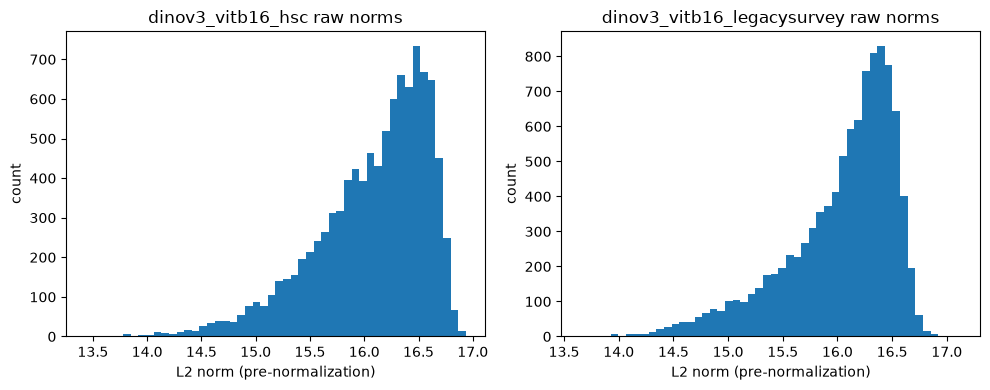

=== HSC raw norm stats (dinov3_vitb16_hsc) ===
  min      = 13.429140
  median   = 16.198719
  mean     = 16.074182
  max      = 16.935687
  std      = 0.520519
  cv       = 0.032382
=== LS raw norm stats (dinov3_vitb16_legacysurvey) ===
  min      = 13.649206
  median   = 16.170909
  mean     = 16.029334
  max      = 17.129603
  std      = 0.503644
  cv       = 0.031420
HSC CV=3.238% is below the ~5% PITFALLS Pitfall 4 warning threshold; LS CV=3.142% is below it.


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(HSC_NORMS, bins=50)
axes[0].set_title("dinov3_vitb16_hsc raw norms")
axes[0].set_xlabel("L2 norm (pre-normalization)")
axes[0].set_ylabel("count")
axes[1].hist(LS_NORMS, bins=50)
axes[1].set_title("dinov3_vitb16_legacysurvey raw norms")
axes[1].set_xlabel("L2 norm (pre-normalization)")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()

# These are the raw pre-normalization norms cached by subsample.py (D-06) specifically
# so this histogram is reproducible from the cached artifact without re-streaming the
# ~553 MiB parquet.

def _norm_stats(x):
    return {
        "min": float(np.min(x)),
        "median": float(np.median(x)),
        "mean": float(np.mean(x)),
        "max": float(np.max(x)),
        "std": float(np.std(x)),
        "cv": float(np.std(x) / np.mean(x)),
    }

HSC_NORM_STATS = _norm_stats(HSC_NORMS)
LS_NORM_STATS = _norm_stats(LS_NORMS)

print("=== HSC raw norm stats (dinov3_vitb16_hsc) ===")
for _k, _v in HSC_NORM_STATS.items():
    print(f"  {_k:8s} = {_v:.6f}")
print("=== LS raw norm stats (dinov3_vitb16_legacysurvey) ===")
for _k, _v in LS_NORM_STATS.items():
    print(f"  {_k:8s} = {_v:.6f}")

_warn_threshold = 0.05
_hsc_side = "above" if HSC_NORM_STATS["cv"] > _warn_threshold else "below"
_ls_side = "above" if LS_NORM_STATS["cv"] > _warn_threshold else "below"
print(
    f"HSC CV={HSC_NORM_STATS['cv']*100:.3f}% is {_hsc_side} the ~5% PITFALLS Pitfall 4 "
    f"warning threshold; LS CV={LS_NORM_STATS['cv']*100:.3f}% is {_ls_side} it."
)

PITFALLS Pitfall 4's warning sign is a coefficient of variation (`std/mean`) above
roughly **5%**: above that figure, Euclidean and cosine neighbourhoods are expected to
diverge materially, whereas a tight spike near a constant norm would mean the metric
choice was close to cosmetic either way. The printed CV percentages and verdict
immediately above report which case this dataset actually falls into for both columns
-- this is reporting, not branching. The metric decision below is stated unconditionally
regardless of which side the observed data lands on (see §2.2).

### §2.2 Metric decision (locked)

**The pipeline L2-normalizes both paired columns and then uses Euclidean distance --
`Isomap`'s default `metric="minkowski", p=2`.** For unit-norm vectors, squared Euclidean
distance equals `2(1 - cos)`, so it is monotone in cosine similarity and the k-NN sets
match cosine exactly. This reconciles Isomap's manifold with the geometry MKNN
implicitly uses in Phase 4.

**This is a locked decision, not decided at runtime from the histogram above.** The
histogram in §2.1 is the justification a reader can inspect, not a branch condition.
Stated plainly because DATA-04's most literal reading would have been "decide from the
histogram", and this pipeline deliberately does not: the normalize-then-Euclidean choice
was made once, in `subsample.py`, before this notebook cell ever ran, and holds
regardless of whether the observed CV above landed above or below the ~5% figure.

**Why normalize-then-Euclidean rather than `metric="cosine"` directly on `Isomap`:**
cosine distance (`1 - cos`) is not a metric in the strict sense classical MDS's
Euclidean-embeddability assumptions rely on, and Phase 2's eigenspectrum audit is exactly
that assumption being tested. Normalizing onto the unit sphere and then using true
Euclidean distance keeps that assumption valid while still matching cosine's neighbor
rankings exactly.

**Normalization happens in `subsample.py` at cache-write time and applies to both
columns** (D-06), so the cache holds only normalized arrays -- Phase 4 cannot
accidentally compare a normalized embedding against a raw one.

**Downstream consequence, carried forward explicitly so it cannot be lost:** the ambient
space is now the unit sphere S^767, which is itself intrinsically curved. Phase 3's
synthetic-control falsification manifolds (CURV-06) must therefore be matched **on the
sphere**, not against a flat plane in R^768, or the control compares against the wrong
baseline.

No cell output in this section embeds a bulk array -- the figure and the summary tables
only, per the §0.4 output-hygiene policy.

## §3. compute_dim pre-audit and n_components

### §3.1 Full estimator panel

In [17]:
import importlib.metadata
import math
import statistics

import effdim
from pu_manifold import json_cache

effdim_version = importlib.metadata.version("effdim")

# Same narrow field set as the load_subsample cache key (see §1.6), plus the resolved
# effdim version, so an effdim upgrade busts this panel's cache key rather than
# silently reusing a stale panel.
effdim_panel_cfg = {
    "dataset": ANALYSIS_CFG["dataset"],
    "seed": ANALYSIS_CFG["seed"],
    "n_rows": ANALYSIS_CFG["n_rows"],
    "normalize": ANALYSIS_CFG["normalize"],
    "datasets_version": datasets.__version__,
    "numpy_version": np.__version__,
    "effdim_version": effdim_version,
}


def _compute_panel():
    # LS is the normalized legacysurvey array from §1.6 (D-05/D-06: the normalized
    # array is the canonical input). compute_dim centers internally (_ensure_centered,
    # tol 1e-5) and computes k-NN distances once via FAISS (k=10), shared across the
    # geometric estimators -- this cell does neither of those itself.
    return effdim.compute_dim(LS)


PANEL = json_cache(
    f"effdim_panel_{SEED}_{analysis_subsample_key}", effdim_panel_cfg, _compute_panel
)
print(f"effdim version = {effdim_version}")
print(f"PANEL cached under stem effdim_panel_{SEED}_{analysis_subsample_key}")

effdim version = 0.1.1
PANEL cached under stem effdim_panel_20260729_a79b3460b838fd0a


In [18]:
GEOMETRIC_KEYS = (
    "mle_dimensionality",
    "two_nn_dimensionality",
    "danco_dimensionality",
    "mind_mli_dimensionality",
    "mind_mlk_dimensionality",
    "ess_dimensionality",
    "tle_dimensionality",
    "gmst_dimensionality",
)

SPECTRAL_KEYS = (
    "pca_explained_variance_95",
    "participation_ratio",
    "shannon_entropy",
    "stable_rank",
    "numerical_rank",
    "cumulative_eigenvalue_ratio",
    "renyi_eff_dimensionality_alpha_2",
    "renyi_eff_dimensionality_alpha_3",
    "renyi_eff_dimensionality_alpha_4",
    "renyi_eff_dimensionality_alpha_5",
    "geometric_mean_eff_dimensionality",
)

print("=== Geometric / intrinsic estimators (INCLUDED in the D-12 rule) ===")
for _k in GEOMETRIC_KEYS:
    print(f"  {_k:28s} = {PANEL[_k]}")

print("=== Spectral estimators (EXCLUDED from the rule, reported for ISO-03) ===")
for _k in SPECTRAL_KEYS:
    print(f"  {_k:35s} = {PANEL[_k]}")

for _k in GEOMETRIC_KEYS:
    assert _k in PANEL, f"Geometric key {_k!r} missing from PANEL -- effdim API drift?"
    assert np.isfinite(PANEL[_k]), f"PANEL[{_k!r}] = {PANEL[_k]} is not finite."
print("All eight geometric keys present in PANEL and finite.")

=== Geometric / intrinsic estimators (INCLUDED in the D-12 rule) ===
  mle_dimensionality           = 18.816747665405273
  two_nn_dimensionality        = 20.047028759699103
  danco_dimensionality         = 5.1519269943237305
  mind_mli_dimensionality      = 0.7039346098899841
  mind_mlk_dimensionality      = 17.23051643371582
  ess_dimensionality           = 0.21579337120056152
  tle_dimensionality           = 18.816747665405273
  gmst_dimensionality          = 17.135909673737896
=== Spectral estimators (EXCLUDED from the rule, reported for ISO-03) ===
  pca_explained_variance_95           = 90
  participation_ratio                 = 8.56061425448953
  shannon_entropy                     = 23.900161532349113
  stable_rank                         = 3.9278131341912568
  numerical_rank                      = 768
  cumulative_eigenvalue_ratio         = 0.9762039304847914
  renyi_eff_dimensionality_alpha_2    = 8.56061425448953
  renyi_eff_dimensionality_alpha_3    = 6.42751103523195
  reny

**Caveat, stated honestly (ARCHITECTURE.md Integration Points).** The comparison across
the whole panel above is not apples-to-apples. The eventual Isomap/MDS eigenspectrum
(Phase 2) operates on *geodesic* distances, so methodologically it sits closer to the
geometric estimators (local, nonlinear-aware) than to the spectral estimators (global,
linear/PCA-based). Expect the spectral panel to read noticeably *higher* than both the
geometric panel and the eventual Isomap elbow whenever the manifold is meaningfully
curved -- a curved low-dimensional manifold can still need many linear components to
represent faithfully in a 768-d ambient space. **That disagreement is not a bug in the
comparison** -- it is, incidentally, direct supporting evidence for this milestone's own
premise (linear/spectral dimension estimates inflate under curvature), and is called out
here as narrative rather than treated as noise.

**Verified fact, not assumed:** at `LS.shape = (10000, 768)`, `compute_dim`'s internal
`_do_svd` takes the **full** `np.linalg.svd` path, because
`min(n_samples, n_features) = min(10000, 768) = 768`, which is below the `1000` threshold
in `_do_svd` (`src/effdim/api.py:144`). The randomized-SVD branch (the `else` arm of `_do_svd`) is not exercised by
this call, so its timing and nondeterminism characteristics do not apply here.

### §3.2 The D-12 selection rule

In [19]:
# Redeclared here (identical to the tuple in the §3.1 panel cell) so the D-12 rule
# is fully self-contained in this cell: the exact 8 literal geometric-key strings
# feeding math.ceil(median(...)) are visible together with the computation itself.
GEOMETRIC_KEYS = (
    "mle_dimensionality",
    "two_nn_dimensionality",
    "danco_dimensionality",
    "mind_mli_dimensionality",
    "mind_mlk_dimensionality",
    "ess_dimensionality",
    "tle_dimensionality",
    "gmst_dimensionality",
)

geometric_values = [PANEL[k] for k in GEOMETRIC_KEYS]
median_value = statistics.median(geometric_values)
N_COMPONENTS = math.ceil(median_value)

print("Geometric estimator values (the 8-key input to the D-12 rule):")
for _k, _v in zip(GEOMETRIC_KEYS, geometric_values):
    print(f"  {_k:28s} = {_v}")
print(f"median(geometric values) = {median_value}")
print(f"N_COMPONENTS = ceil(median) = {N_COMPONENTS}")

ANALYSIS_CFG["n_components"] = N_COMPONENTS
fit_key = config_key(ANALYSIS_CFG)
print(f"ANALYSIS_CFG['n_components'] set to {N_COMPONENTS}")
print(f"fit_key (config_key(ANALYSIS_CFG)) = {fit_key}")

Geometric estimator values (the 8-key input to the D-12 rule):
  mle_dimensionality           = 18.816747665405273
  two_nn_dimensionality        = 20.047028759699103
  danco_dimensionality         = 5.1519269943237305
  mind_mli_dimensionality      = 0.7039346098899841
  mind_mlk_dimensionality      = 17.23051643371582
  ess_dimensionality           = 0.21579337120056152
  tle_dimensionality           = 18.816747665405273
  gmst_dimensionality          = 17.135909673737896
median(geometric values) = 17.18321305372686
N_COMPONENTS = ceil(median) = 18
ANALYSIS_CFG['n_components'] set to 18
fit_key (config_key(ANALYSIS_CFG)) = 80ce249fedcf55e0


- **The median is over eight values, not seven.** CONTEXT.md's D-12 prose abbreviates
  two distinct estimators as `MiND-ML*`; they are separate result-dict keys
  (`mind_mli_dimensionality` and `mind_mlk_dimensionality`) and both count -- confirmed by
  `GEOMETRIC_KEYS` above holding exactly eight literal strings.
- **No headroom is added.** `N_COMPONENTS` is exactly `math.ceil(median(...))`. The user
  chose the library's own unpadded, data-informed answer over a headroom constant, and
  explicitly accepted the consequence below.
- **The rounding contract is `math.ceil` on the float median -- half-values round up,
  never half-to-even, never truncated.** Stated explicitly because it is the tie-breaking
  behaviour a reader would otherwise have to infer.
- Spectral estimators are excluded from the rule because they are ambient-linear and
  inflate under curvature (ARCHITECTURE.md Integration Points, §3.1 above), but the full
  panel is still reported for the ISO-03 comparison.
- **Accepted risk, stated plainly:** if Phase 2's residual-variance elbow (SPEC-04) lands
  above `N_COMPONENTS`, the Isomap fit must be **re-fit** at the larger dimension,
  re-paying minutes of compute and a new ~1 GB cache entry. Because `n_components` is a
  cache-key field (D-14), that re-fit produces a new key automatically and needs no
  manual cache invalidation -- which is what makes the branch cheap for Phase 2 to take.
  Phase 2 planning should treat "elbow exceeds the Phase 1 fit dimension" as a real
  branch, not an edge case.

### §3.3 Provisional d (resolving the D-10 circularity)

In [20]:
D_PROVISIONAL = N_COMPONENTS

print("=== D_PROVISIONAL (resolves the D-10 circularity) ===")
print(f"d_provisional = n_components = {D_PROVISIONAL}")
print("source: ceil(median(...)) over the 8 geometric compute_dim keys per D-12, no headroom")
print("frozen before the section 4 n_neighbors sweep exists (plan 03), so it cannot be")
print("  tuned to the sweep's own output")
print("Phase 2's residual-variance elbow may differ; if it exceeds D_PROVISIONAL, the")
print("  Isomap fit is re-fit at the larger dimension (see §3.2's accepted-risk note)")

=== D_PROVISIONAL (resolves the D-10 circularity) ===
d_provisional = n_components = 18
source: ceil(median(...)) over the 8 geometric compute_dim keys per D-12, no headroom
frozen before the section 4 n_neighbors sweep exists (plan 03), so it cannot be
  tuned to the sweep's own output
Phase 2's residual-variance elbow may differ; if it exceeds D_PROVISIONAL, the
  Isomap fit is re-fit at the larger dimension (see §3.2's accepted-risk note)


**Why this resolves rather than dodges the D-10 circularity**, per this plan's own
`<discretion_resolved>` reasoning:

1. **Not circular in the harmful direction.** `compute_dim` runs on the raw normalized
   768-d embeddings and never sees the geodesic graph. Using a number derived from
   ambient-space estimators to judge geodesic-graph stability does not let the sweep's
   own output influence the criterion that judges it.
2. **Removes an arbitrary knob rather than adding one.** Every sweep fit uses
   `n_components=N_COMPONENTS`, so `Isomap.kernel_pca_.eigenvalues_` has exactly
   `N_COMPONENTS` entries and "the leading `d`" means "all of them." There is no
   truncation choice left to make, and therefore nothing to tune.
3. **Frozen before the sweep exists.** `N_COMPONENTS`/`D_PROVISIONAL` are computed here in
   §3; the `n_neighbors` sweep is §4, plan 03. The pre-registration ordering is
   structural, not a matter of discipline.

The full classical-MDS eigenspectrum, the negative-eigenvalue statistic, the
residual-variance elbow, the frozen final `d`, and the PASS/MARGINAL/FAIL verdict are all
**Phase 2's** deliverables (SPEC-01 through SPEC-07) and are deliberately absent from
§0-§5 of this notebook.

## §4. n_neighbors sweep

### §4.0 Pre-registered sweep constants

**This cell is the pre-registration point.** Every threshold and every range used by the
rest of §4 (this plan) and §5 (plan 04) is fixed in the code cell immediately below,
before a single Isomap fit in §4.2 has run. The notebook asserts that cell ordering
mechanically at the end of §4.3 — not left to reading discipline. The reason is stated
plainly: the milestone has an explicit garden-of-forking-paths concern, and a threshold
chosen after seeing the sweep's own results would make the resulting stability verdict
unfalsifiable.

**Why these three thresholds:**

- **Procrustes disparity, `<= 0.10`.** `scipy.spatial.procrustes(A, B)` normalizes both
  configurations to unit Frobenius norm, applies the optimal rotation and scaling, and
  returns a disparity in `[0, 1]` — the sum of squared differences after that alignment.
  Procrustes rather than a raw coordinate difference is the point: it absorbs the axis
  sign/rotation ambiguity inherent to any eigendecomposition-based embedding (not a bug to
  fix, per ARCHITECTURE.md's Determinism section), while staying decisively sensitive to a
  short-circuit edge rerouting many shortest paths and moving a large fraction of points
  (PITFALLS Pitfall 2). `0.10` means at least 90% of the normalized configuration variance
  is shared after optimal alignment — loose enough for the genuine smooth deformation
  expected as k grows, tight enough to fail decisively on a real short-circuit.
- **Relative leading-eigenvalue change, `<= 0.15`, self-normalized.** For adjacent
  `k1 < k2`, the statistic is
  `max_i | lam_i(k2)/lam_1(k2) - lam_i(k1)/lam_1(k1) |` over `i` in `1..N_COMPONENTS`. Each
  spectrum is divided by its own leading eigenvalue before comparison — load-bearing,
  because geodesic distances shrink smoothly as k grows and every eigenvalue drifts
  downward together; an un-normalized comparison would trip on that uniform rescaling
  rather than on a genuine change of shape. Isomap's global scale is arbitrary anyway
  (FEATURES.md section 4); what this metric measures is whether the *shape* of the leading
  spectrum is stable. `0.15` is a meaningful fraction of the statistic's maximum possible
  value of `1.0`, not an arbitrarily tiny number.
- **Spearman correlation of geodesic distances, `>= 0.95`,** computed on a fixed sample of
  `GEO_PAIR_COUNT = 100_000` index pairs drawn once below and reused unchanged for every
  adjacent-k comparison, so the comparison is apples-to-apples across k. PITFALLS Pitfall 2
  states this almost verbatim: the rank ordering of pairwise geodesic distances for a fixed
  random subset of point pairs should change smoothly as `n_neighbors` is nudged, and a
  sharp discontinuity is the signature of a short-circuit edge switching on or off. Spearman
  is precisely that rank-order statistic. Sampling — rather than all ~50 million pairs — is
  what keeps each slim npz inside D-13's ~1 MB budget; 100,000 pairs is far more than enough
  to distinguish 0.95 from 0.99.

**Boundary contracts, spelled out so a reader never has to infer them:** `K_CEILING` is
**inclusive** — k=50 is tried, k=51 is never tried and the halt fires instead.
`K_WARN_ABOVE` is **strict** — k=30 does not warn, k=31 does. The connectivity pass
condition is exactly `connected_components == 1`, so a count of 2 fails.

**Determinism and rounding contracts:** `eigen_solver` is pinned to `"dense"` throughout
this milestone — `Isomap` exposes no `random_state`, and the `"auto"`/`"arpack"` paths use
ARPACK with a random start vector, so `"dense"` is what makes every fit deterministic LAPACK
with no run-to-run drift. `N_COMPONENTS` (`= 18`, plan 02 §3.2) was fixed by `math.ceil`
applied to the geometric-estimator median, so half-values round up and never
half-to-even. The geodesic Spearman metric is computed on a fixed, seeded `GEO_PAIR_COUNT`
pair sample, so it is reproducible across k. Plateau run-length ties break to the **lower**
k (`PLATEAU_TIE_BREAK = "lower"`).

**The plateau selection rule, pre-registered here and applied by plan 04:** `k*` is the
centre of the widest maximal run of consecutive *swept* k values in which all three
adjacent-pair metrics pass. A run spanning `m` swept values contains `m-1` adjacent pairs;
`MIN_PLATEAU_RUN = 3` requires at least two consecutive passing adjacent pairs. The centre
of an even-length run is the lower-index (smaller k) member. If no run of length `>= 3`
exists, there is no defensible plateau, and the notebook halts with the remediation options
enumerated in §4.1 rather than silently substituting a different criterion such as
smallest-connected-k.


In [21]:
import warnings

# --- D-09 stage-1 base range and D-11 bounded auto-extend ladder ---
SWEEP_K_RANGE = (5, 8, 10, 15, 20, 30)
K_EXTENSIONS = (40, 50)
K_CEILING = 50  # inclusive: k=50 is tried, k=51 is never tried
K_WARN_ABOVE = 30  # strict: k=30 does not warn, k=31 does

# --- D-10 plateau criterion: three thresholds, fixed before any fit exists ---
PLATEAU_THRESH = {
    "procrustes_disparity_max": 0.10,
    "eig_rel_change_max": 0.15,
    "geodesic_spearman_min": 0.95,
}

GEO_PAIR_COUNT = 100_000
GEO_PAIR_SEED = SEED + 1
MIN_PLATEAU_RUN = 3
STAGE2_MAX_FITS = 4
PLATEAU_TIE_BREAK = "lower"


def _draw_geo_pairs(rng, n_rows_total, count):
    """Draw `count` off-diagonal (row, col) index pairs, self-pairs rejected and redrawn."""
    rows = rng.integers(0, n_rows_total, size=count)
    cols = rng.integers(0, n_rows_total, size=count)
    self_pairs = rows == cols
    while np.any(self_pairs):
        n_bad = int(self_pairs.sum())
        cols[self_pairs] = rng.integers(0, n_rows_total, size=n_bad)
        self_pairs = rows == cols
    return rows, cols


_geo_pair_rng = np.random.default_rng(GEO_PAIR_SEED)
GEO_PAIR_ROWS, GEO_PAIR_COLS = _draw_geo_pairs(_geo_pair_rng, len(LS), GEO_PAIR_COUNT)

assert GEO_PAIR_ROWS.shape == (GEO_PAIR_COUNT,)
assert GEO_PAIR_COLS.shape == (GEO_PAIR_COUNT,)
assert not np.any(GEO_PAIR_ROWS == GEO_PAIR_COLS), "self-pairs present in GEO_PAIR_ROWS/COLS"

print("=== Section 4.0: pre-registered sweep constants ===")
print("SWEEP_K_RANGE     =", SWEEP_K_RANGE)
print("K_EXTENSIONS      =", K_EXTENSIONS)
print("K_CEILING         =", K_CEILING, "(inclusive)")
print("K_WARN_ABOVE      =", K_WARN_ABOVE, "(strict: > this warns)")
print("PLATEAU_THRESH    =", PLATEAU_THRESH)
print("GEO_PAIR_COUNT    =", GEO_PAIR_COUNT)
print("GEO_PAIR_SEED     =", GEO_PAIR_SEED)
print("MIN_PLATEAU_RUN   =", MIN_PLATEAU_RUN)
print("STAGE2_MAX_FITS   =", STAGE2_MAX_FITS)
print("PLATEAU_TIE_BREAK =", PLATEAU_TIE_BREAK)
print(f"GEO_PAIR_ROWS/COLS length = {len(GEO_PAIR_ROWS)}")
print(
    "first three pairs:",
    list(zip(GEO_PAIR_ROWS[:3].tolist(), GEO_PAIR_COLS[:3].tolist())),
)


=== Section 4.0: pre-registered sweep constants ===
SWEEP_K_RANGE     = (5, 8, 10, 15, 20, 30)
K_EXTENSIONS      = (40, 50)
K_CEILING         = 50 (inclusive)
K_WARN_ABOVE      = 30 (strict: > this warns)
PLATEAU_THRESH    = {'procrustes_disparity_max': 0.1, 'eig_rel_change_max': 0.15, 'geodesic_spearman_min': 0.95}
GEO_PAIR_COUNT    = 100000
GEO_PAIR_SEED     = 20260730
MIN_PLATEAU_RUN   = 3
STAGE2_MAX_FITS   = 4
PLATEAU_TIE_BREAK = lower
GEO_PAIR_ROWS/COLS length = 100000
first three pairs: [(9075, 4520), (9785, 6298), (4620, 2179)]


### §4.1 Stage 1 — connectivity scan (ISO-01)

D-09's cheap stage: build only the k-NN graph for each candidate k and count connected
components. **No Isomap fit happens in this section** — that is the entire point. The scan
below completes for every candidate k in `SWEEP_K_RANGE` (and any auto-extended k) before
any fit anywhere in this notebook is trusted.

**The mechanism this scan exists to catch (PITFALLS Pitfall 1).** `sklearn.manifold.Isomap`
does **not** raise when its k-NN graph is disconnected. It emits a `UserWarning` and
silently calls an internal graph-completion routine (`_fix_connected_components`) that
bridges components with artificial long edges between the nearest cross-component point
pair. The notebook then runs to completion and produces an embedding and an eigenspectrum
built on geodesic distances that include fabricated edges corresponding to no real path
along the data. Running this scan *before* fitting anything is the only way that cannot pass
unnoticed — a `UserWarning` sitting in cell output is not a substitute for an assertion.


In [22]:
import time

from scipy.sparse.csgraph import connected_components
from sklearn.neighbors import kneighbors_graph


def _scan_k(k):
    """Build the k-NN graph only (no Isomap fit) and count connected components."""
    t0 = time.perf_counter()
    graph = kneighbors_graph(LS, n_neighbors=k, mode="distance", n_jobs=-1)
    n_components, labels = connected_components(graph, directed=False)
    sizes = np.bincount(labels)
    scan_seconds = time.perf_counter() - t0
    return {
        "k": k,
        "n_components": int(n_components),
        "largest_component": int(sizes.max()),
        "smallest_component": int(sizes.min()),
        "scan_seconds": scan_seconds,
    }


CONNECTIVITY_SCAN = [_scan_k(k) for k in SWEEP_K_RANGE]

print("=== Section 4.1: connectivity scan (base range, all six k) ===")
print(f"{'k':>4} {'n_components':>13} {'largest':>8} {'smallest':>9} {'scan_s':>8}")
for row in CONNECTIVITY_SCAN:
    print(
        f"{row['k']:>4} {row['n_components']:>13} {row['largest_component']:>8} "
        f"{row['smallest_component']:>9} {row['scan_seconds']:>8.3f}"
    )

CONNECTED_K = [row["k"] for row in CONNECTIVITY_SCAN if row["n_components"] == 1]

if not CONNECTED_K:
    print(
        "\nNo base-range k is connected -- entering the bounded auto-extend ladder "
        f"K_EXTENSIONS = {K_EXTENSIONS} (K_CEILING = {K_CEILING}, inclusive)."
    )
    for k in K_EXTENSIONS:
        row = _scan_k(k)
        CONNECTIVITY_SCAN.append(row)
        print(
            f"  extended k={k}: n_components={row['n_components']}, "
            f"largest={row['largest_component']}, smallest={row['smallest_component']}, "
            f"scan_s={row['scan_seconds']:.3f}"
        )
        if row["n_components"] == 1:
            CONNECTED_K = [k]
            break
    else:
        assert False, (
            "k-NN graph connectivity scan reached K_CEILING=50 (inclusive) and no k in "
            f"SWEEP_K_RANGE + K_EXTENSIONS = {SWEEP_K_RANGE + K_EXTENSIONS} yields a "
            "single connected component. A documented halt here is a legitimate, "
            "complete result -- the same posture Phase 2's gate takes -- not a crash. "
            "Three remediation options: "
            "(1) widen the k range beyond the K_CEILING=50 bound; "
            "(2) resample with a new seed and re-derive row_indices; "
            "(3) restrict to the largest connected component and re-derive row_indices "
            "from that subset."
        )

K_SMALLEST_CONNECTED = min(CONNECTED_K)
SHORT_CIRCUIT_RISK = K_SMALLEST_CONNECTED > K_WARN_ABOVE

print(f"\nCONNECTED_K = {CONNECTED_K}")
print(f"K_SMALLEST_CONNECTED = {K_SMALLEST_CONNECTED}")
print(
    f"SHORT_CIRCUIT_RISK = {SHORT_CIRCUIT_RISK} "
    f"(strict comparison: K_SMALLEST_CONNECTED > K_WARN_ABOVE={K_WARN_ABOVE})"
)

if SHORT_CIRCUIT_RISK:
    warnings.warn(
        f"SHORT_CIRCUIT_RISK: smallest connected k ({K_SMALLEST_CONNECTED}) is above "
        f"K_WARN_ABOVE ({K_WARN_ABOVE}). Phase 2's gate must weigh this flag."
    )
    print("=" * 78)
    print(
        f"!!! SHORT-CIRCUIT RISK: smallest connected k = {K_SMALLEST_CONNECTED} "
        f"> K_WARN_ABOVE = {K_WARN_ABOVE} !!!"
    )
    print(
        "This flag must propagate to Phase 2's gate and be weighed there -- it is not"
    )
    print("silently consumed here.")
    print("=" * 78)
else:
    print(
        f"SHORT_CIRCUIT_RISK is False: K_SMALLEST_CONNECTED={K_SMALLEST_CONNECTED} "
        f"<= K_WARN_ABOVE={K_WARN_ABOVE}."
    )


=== Section 4.1: connectivity scan (base range, all six k) ===
   k  n_components  largest  smallest   scan_s
   5             1    10000     10000    3.013
   8             1    10000     10000    3.150
  10             1    10000     10000    3.336
  15             1    10000     10000    3.143
  20             1    10000     10000    3.115
  30             1    10000     10000    3.124

CONNECTED_K = [5, 8, 10, 15, 20, 30]
K_SMALLEST_CONNECTED = 5
SHORT_CIRCUIT_RISK = False (strict comparison: K_SMALLEST_CONNECTED > K_WARN_ABOVE=30)
SHORT_CIRCUIT_RISK is False: K_SMALLEST_CONNECTED=5 <= K_WARN_ABOVE=30.


**The D-11 tension, recorded rather than silently resolved the other way.**
Auto-extending k upward to force connectivity moves toward the very short-circuit regime
ISO-02 exists to detect. The user chose auto-extend over halting immediately, and chose a
bounded ceiling (`K_CEILING = 50`) over unbounded extension. That choice stands here. The
mitigation is the loud above-`K_WARN_ABOVE` flag and its propagation to Phase 2's gate, not
a quiet reversal to halt-first behaviour.

**Boundary contracts, restated at the point of use:** the ceiling is inclusive (k=50 is
tried, k=51 never is), the warn boundary is strict (k=30 does not warn, k=31 does), and the
connectivity pass condition is exactly one component (`connected_components == 1`; a count
of 2 fails).

**What a nominally-disconnected result means in practice.** Reporting the component *size*
distribution (largest/smallest, derived from `np.bincount` on the component labels)
alongside the raw count distinguishes a graph with one two-point outlier component from one
genuinely fragmented into comparable-sized pieces — and those two cases warrant different
remediation choices even though both report `n_components > 1`.


### §4.2 Stage 2 — full fits at surviving k (ISO-02)

D-09's expensive stage, spent only where it buys the ISO-02 answer: full `Isomap` fits at
the 3-4 `n_neighbors` values that survived §4.1's cheap scan, each independently
re-verified for connectivity and persisted as a slim ~1 MB `sweep_k{K}_{key_K}.npz` that
deliberately excludes the ~763 MiB `dist_matrix_` (D-13).


In [23]:
def _stage2_k_selection(connected_k, max_fits):
    """
    Deterministic selection of up to `max_fits` values from `connected_k`: if
    `connected_k` already has `max_fits` or fewer entries, keep all of them; otherwise
    take `max_fits` values evenly spaced across the sorted range, always including both
    endpoints, which maximizes the span the plateau criterion (§4.0) can see.
    """
    values = sorted(connected_k)
    if len(values) <= max_fits:
        return values
    n = len(values)
    idx = sorted(set(int(round(x)) for x in np.linspace(0, n - 1, max_fits)))
    while len(idx) < max_fits:
        remaining = [i for i in range(n) if i not in idx]
        idx.append(min(remaining, key=lambda i: min(abs(i - j) for j in idx)))
        idx = sorted(idx)
    return [values[i] for i in idx]


STAGE2_K = _stage2_k_selection(CONNECTED_K, STAGE2_MAX_FITS)

assert len(STAGE2_K) >= 3, (
    f"ISO-02 requires at least three n_neighbors values in stage 2 to exhibit a "
    f"stability plateau; STAGE2_K = {STAGE2_K} has only {len(STAGE2_K)}. A two-value "
    f"comparison cannot show a plateau -- halting rather than reporting a degenerate "
    f"comparison. Remediation: widen SWEEP_K_RANGE / K_EXTENSIONS so more base-range k "
    f"values are connected, per §4.1's remediation options."
)
assert len(STAGE2_K) <= STAGE2_MAX_FITS, (
    f"STAGE2_K has {len(STAGE2_K)} entries, exceeding STAGE2_MAX_FITS={STAGE2_MAX_FITS}."
)

print(f"CONNECTED_K = {CONNECTED_K}")
print(
    f"STAGE2_K = {STAGE2_K}  ({len(STAGE2_K)} of {len(CONNECTED_K)} connected k values, "
    f"STAGE2_MAX_FITS={STAGE2_MAX_FITS})"
)


CONNECTED_K = [5, 8, 10, 15, 20, 30]
STAGE2_K = [5, 10, 15, 30]  (4 of 6 connected k values, STAGE2_MAX_FITS=4)


In [24]:
from pu_manifold import cache_path, npz_cache

_expected_dist_matrix_bytes = 10_000 * 10_000 * 8
print(
    f"Expected per-fit dist_matrix_ size: {_expected_dist_matrix_bytes / 1024**2:.0f} MiB "
    f"({_expected_dist_matrix_bytes / 1024**3:.2f} GiB) -- NEVER persisted for a swept k "
    f"(D-13)."
)
print(
    "KernelPCA builds a second n-by-n centered-kernel array internally during .fit(), so "
    "expect a transient peak of roughly 2-3 GiB per fit, not just the ~763 MiB matrix "
    "itself (T-01-05)."
)

STAGE2_SWEEP = True  # cell-ordering anchor: must not appear earlier than PLATEAU_THRESH

STAGE2_RECORDS = {}
STAGE2_NPZ_PATHS = {}

for k in STAGE2_K:
    fit_cfg = dict(ANALYSIS_CFG)
    fit_cfg["n_neighbors"] = k
    key_k = config_key(fit_cfg)
    stem = f"sweep_k{k}_{key_k}"

    def _fit_k(k=k):
        t0 = time.perf_counter()
        model = Isomap(
            n_neighbors=k,
            n_components=N_COMPONENTS,
            eigen_solver="dense",
            n_jobs=-1,
            path_method="auto",
        )
        model.fit(LS)
        fit_seconds = time.perf_counter() - t0

        # Independent re-verification: does the fitted estimator's own neighbour graph
        # agree with §4.1's stage-1 scan for this k? The stage-1 scan result and what the
        # fitted object actually used must not silently diverge (T-01-08).
        fitted_graph = model.nbrs_.kneighbors_graph(mode="distance")
        n_components_fit, _ = connected_components(fitted_graph, directed=False)

        # Load-bearing (D-13): geo_pairs must be sampled HERE, while dist_matrix_ is
        # still in memory, because dist_matrix_ itself is never persisted for a swept k.
        geo_pairs = model.dist_matrix_[GEO_PAIR_ROWS, GEO_PAIR_COLS].astype(np.float32)

        return {
            "embedding": model.embedding_.astype(np.float32),
            "eigenvalues_truncated": np.asarray(
                model.kernel_pca_.eigenvalues_, dtype=np.float64
            ),
            "n_connected_components": np.array(n_components_fit),
            "fit_seconds": np.array(fit_seconds),
            "geo_pairs": geo_pairs,
            "geo_pair_count": np.array(GEO_PAIR_COUNT),
            "geo_pair_seed": np.array(GEO_PAIR_SEED),
        }

    record = npz_cache(stem, fit_cfg, _fit_k)
    STAGE2_RECORDS[k] = record
    STAGE2_NPZ_PATHS[k] = cache_path(stem, "npz")

print(f"\nStage-2 fits complete for STAGE2_K = {STAGE2_K}")
print("\n=== Section 4.2: stage-2 fit summary ===")
print(f"{'k':>4} {'n_conn':>7} {'fit_s':>8} {'npz MiB':>9}  eigenvalues_truncated[:5]")
for k in STAGE2_K:
    rec = STAGE2_RECORDS[k]
    npz_path = STAGE2_NPZ_PATHS[k]
    size_mib = npz_path.stat().st_size / 1024**2
    eig5 = np.asarray(rec["eigenvalues_truncated"])[:5]
    print(
        f"{k:>4} {int(rec['n_connected_components']):>7} "
        f"{float(rec['fit_seconds']):>8.2f} {size_mib:>9.3f}  {eig5}"
    )


Expected per-fit dist_matrix_ size: 763 MiB (0.75 GiB) -- NEVER persisted for a swept k (D-13).
KernelPCA builds a second n-by-n centered-kernel array internally during .fit(), so expect a transient peak of roughly 2-3 GiB per fit, not just the ~763 MiB matrix itself (T-01-05).



Stage-2 fits complete for STAGE2_K = [5, 10, 15, 30]

=== Section 4.2: stage-2 fit summary ===
   k  n_conn    fit_s   npz MiB  eigenvalues_truncated[:5]
   5       1    62.71     1.070  [5432.08611999 3731.44228698 1544.04707286 1049.7316245   666.26524322]
  10       1    69.54     1.070  [3798.25420043 2575.84471458 1047.77378516  723.45472259  488.24952242]
  15       1    94.76     1.070  [3230.85396346 2149.13194055  879.09341975  586.70893018  414.90743209]
  30       1    75.60     1.070  [2528.06548695 1698.26695092  691.7006872   458.84500918  321.96389446]


**`eigenvalues_truncated` is exactly what the name says.** `Isomap.kernel_pca_.eigenvalues_`
is constructed with `n_components` equal to the target embedding dimension, so it returns
only the top-`N_COMPONENTS` algebraically-largest eigenvalues — it **cannot** show a
negative tail no matter how non-Euclidean the true geodesic structure is (PITFALLS Pitfall
3). Phase 1 uses it for exactly one purpose: comparing the *shape* of the leading spectrum
across k in §4.3. No negative-eigenvalue, non-Euclideanity, or Euclidean-embeddability
conclusion is drawn from it here. The full classical-MDS spectrum, computed by manual
double-centring of `dist_matrix_`, is Phase 2's SPEC-01 deliverable and is deliberately
absent from §0-§5 of this notebook.


### §4.3 Adjacent-k stability table (ISO-02)

The three D-10 metrics, computed for every adjacent pair in `STAGE2_K`, reading only from
the cached `sweep_k{K}` npz records above — no re-fitting.


In [25]:
from scipy.spatial import procrustes
from scipy.stats import spearmanr


def _eig_rel_change(eig1, eig2):
    """Max abs difference between the two self-normalized (leading-eigenvalue-scaled)
    profiles -- scale-free, per §4.0's justification."""
    profile1 = eig1 / eig1[0]
    profile2 = eig2 / eig2[0]
    return float(np.max(np.abs(profile1 - profile2)))


STABILITY_TABLE = []
for k1, k2 in zip(STAGE2_K[:-1], STAGE2_K[1:]):
    rec1, rec2 = STAGE2_RECORDS[k1], STAGE2_RECORDS[k2]

    # T-01-03 mitigation: a stale npz built from a different pair sample must not be
    # silently compared against a fresh one.
    assert int(rec1["geo_pair_count"]) == GEO_PAIR_COUNT and int(
        rec2["geo_pair_count"]
    ) == GEO_PAIR_COUNT, (
        f"geo_pair_count mismatch between cached record(s) for k={k1}/{k2} and the "
        f"current GEO_PAIR_COUNT={GEO_PAIR_COUNT} -- a stale npz cannot be compared."
    )
    assert int(rec1["geo_pair_seed"]) == GEO_PAIR_SEED and int(
        rec2["geo_pair_seed"]
    ) == GEO_PAIR_SEED, (
        f"geo_pair_seed mismatch between cached record(s) for k={k1}/{k2} and the "
        f"current GEO_PAIR_SEED={GEO_PAIR_SEED} -- a stale npz cannot be compared."
    )

    emb1 = np.asarray(rec1["embedding"], dtype=np.float64)
    emb2 = np.asarray(rec2["embedding"], dtype=np.float64)
    assert emb1.shape == emb2.shape == (10_000, N_COMPONENTS)
    _, _, procrustes_disparity = procrustes(emb1, emb2)

    eig1 = np.asarray(rec1["eigenvalues_truncated"], dtype=np.float64)
    eig2 = np.asarray(rec2["eigenvalues_truncated"], dtype=np.float64)
    eig_rel_change = _eig_rel_change(eig1, eig2)

    geodesic_spearman, _ = spearmanr(rec1["geo_pairs"], rec2["geo_pairs"])

    procrustes_pass = procrustes_disparity <= PLATEAU_THRESH["procrustes_disparity_max"]
    eig_pass = eig_rel_change <= PLATEAU_THRESH["eig_rel_change_max"]
    spearman_pass = geodesic_spearman >= PLATEAU_THRESH["geodesic_spearman_min"]
    all_three_pass = procrustes_pass and eig_pass and spearman_pass

    STABILITY_TABLE.append(
        {
            "k1": k1,
            "k2": k2,
            "procrustes_disparity": float(procrustes_disparity),
            "eig_rel_change": float(eig_rel_change),
            "geodesic_spearman": float(geodesic_spearman),
            "procrustes_pass": bool(procrustes_pass),
            "eig_pass": bool(eig_pass),
            "spearman_pass": bool(spearman_pass),
            "all_three_pass": bool(all_three_pass),
        }
    )

print("=== Section 4.3: adjacent-k stability table ===")
print(
    f"{'k1':>4} {'k2':>4} {'procrustes':>11} {'eig_rel':>8} {'spearman':>9} "
    f"{'P':>2} {'E':>2} {'S':>2} {'ALL':>5}"
)
for row in STABILITY_TABLE:
    print(
        f"{row['k1']:>4} {row['k2']:>4} {row['procrustes_disparity']:>11.4f} "
        f"{row['eig_rel_change']:>8.4f} {row['geodesic_spearman']:>9.4f} "
        f"{'Y' if row['procrustes_pass'] else 'N':>2} "
        f"{'Y' if row['eig_pass'] else 'N':>2} "
        f"{'Y' if row['spearman_pass'] else 'N':>2} "
        f"{'PASS' if row['all_three_pass'] else 'fail':>5}"
    )


=== Section 4.3: adjacent-k stability table ===
  k1   k2  procrustes  eig_rel  spearman  P  E  S   ALL
   5   10      0.1316   0.0100    0.9676  N  Y  Y  fail
  10   15      0.0699   0.0130    0.9815  Y  Y  Y  PASS
  15   30      0.0803   0.0066    0.9793  Y  Y  Y  PASS


In [26]:
def _maximal_passing_runs(stage2_k, stability_table):
    """
    Maximal runs of consecutive STAGE2_K values where every adjacent pair passes all
    three metrics. Returns a list of {'k_values': [...], 'length': m} dicts, m = number
    of k values in the run (m-1 adjacent pairs).
    """
    pass_by_pair = {(row["k1"], row["k2"]): row["all_three_pass"] for row in stability_table}
    runs = []
    current = [stage2_k[0]]
    for k1, k2 in zip(stage2_k[:-1], stage2_k[1:]):
        if pass_by_pair[(k1, k2)]:
            current.append(k2)
        else:
            if len(current) > 1:
                runs.append(current)
            current = [k2]
    if len(current) > 1:
        runs.append(current)
    return [{"k_values": run, "length": len(run)} for run in runs]


PLATEAU_RUNS = _maximal_passing_runs(STAGE2_K, STABILITY_TABLE)

print("PLATEAU_RUNS (maximal all-three-passing runs):")
if PLATEAU_RUNS:
    for run in PLATEAU_RUNS:
        print(f"  k_values={run['k_values']}  length={run['length']}")
else:
    print("  (none -- no adjacent pair passed all three metrics)")

_max_run_length = max((r["length"] for r in PLATEAU_RUNS), default=0)
_qualifies = _max_run_length >= MIN_PLATEAU_RUN
print(
    f"\nWidest run length = {_max_run_length}; reaches MIN_PLATEAU_RUN={MIN_PLATEAU_RUN}: "
    f"{_qualifies}"
)


PLATEAU_RUNS (maximal all-three-passing runs):
  k_values=[10, 15, 30]  length=3

Widest run length = 3; reaches MIN_PLATEAU_RUN=3: True


**`k*` is not selected here.** `STABILITY_TABLE` and `PLATEAU_RUNS` are the evidence the
Task 4 checkpoint presents to a human, and plan 04 applies the pre-registered plateau
selection rule (§4.0) and freezes the resulting value into the cached ~1 GB Isomap artifact
and `fit_key`. That ordering — compute and compare the metrics here, freeze only after
human confirmation — is deliberate, not an oversight.


In [27]:
import json as _json

_nb_path = Path.cwd() / "01_manifold_and_gate.ipynb"
_nb_json = _json.loads(_nb_path.read_text())
_src = ["".join(c["source"]) for c in _nb_json["cells"]]
_threshold_cell_idx = next(
    i for i, s in enumerate(_src) if "PLATEAU_THRESH" in s and "procrustes_disparity_max" in s
)
_sweep_cell_idx = next(i for i, s in enumerate(_src) if "STAGE2_SWEEP" in s)
assert _threshold_cell_idx < _sweep_cell_idx, (
    f"PRE-REGISTRATION VIOLATED: PLATEAU_THRESH cell (index {_threshold_cell_idx}) must "
    f"precede the STAGE2_SWEEP cell (index {_sweep_cell_idx})."
)
print(
    f"Pre-registration ordering OK: PLATEAU_THRESH cell index {_threshold_cell_idx} < "
    f"STAGE2_SWEEP cell index {_sweep_cell_idx}"
)


Pre-registration ordering OK: PLATEAU_THRESH cell index 61 < STAGE2_SWEEP cell index 67
